In [4]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

# Simulate a toy system of two populations

## Creating ground truth coupling filters and history filters

In [431]:
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 500 # 5000 trials in total
npop = 2 # two populations
nneuron = 1 # ten neurons in each population

time_line = np.arange(nt)
log_lambda_baseline = np.log(0.5) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 
# We assume stimulus is the same for every trial. 

log_lambda_neuron1 = log_lambda_baseline + log_lambda_stimulus
lambda_neuron1 = np.exp(log_lambda_neuron1)
spike_neuron1 = np.random.poisson(lam=np.matlib.repmat(lambda_neuron1[:,np.newaxis],1,ntrial), size=None)


Text(0.5, 1.0, 'ground truth inhomo baseline')

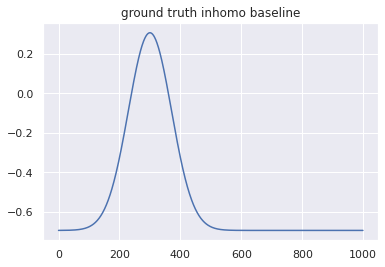

In [356]:
plt.plot(log_lambda_baseline+log_lambda_stimulus)
plt.title('ground truth inhomo baseline')

Text(0.5, 1.0, 'ground truth coupling$')

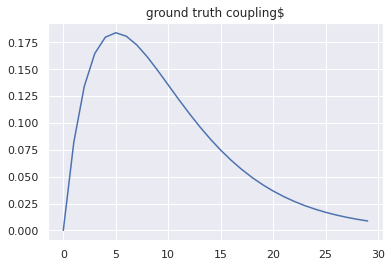

In [357]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 0.1*time_line_coupling*np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth coupling$')

Text(0.5, 1.0, 'ground truth history')

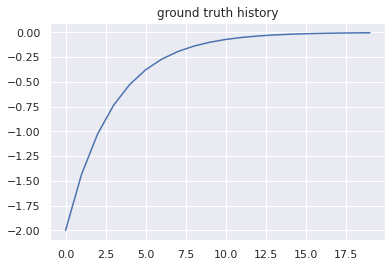

In [439]:
history_length = 20
time_line_history = np.arange(history_length)
ground_truth_history = -2*np.exp(-time_line_history/3)
# ground_truth_history = -3*np.ones_like(time_line_history)
plt.plot(ground_truth_history)
plt.title('ground truth history')

## Simulation

In [ ]:
pop_spikes = [np.zeros((nt, ntrial)) for i in range(npop)]
log_firing_rate_pop_level = [np.zeros((nt, ntrial)) for i in range(npop)]

baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), npop,npop))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
# coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ np.flip(ground_truth_history) for i in range(npop)] 
nneuron_list = [nneuron]*npop

for itrial in range(ntrial):
    
    pop_spikes_single_trial, log_firing_rate_pop_level_single_trial = GLM.simulate_individual_history(baseline_mat, 
                                                                            coupling_mat, 
                                                                            history_list, 
                                                                            nneuron_list=nneuron_list)
    for ipop in range(npop):
        pop_spikes[ipop][:, itrial] = pop_spikes_single_trial[:, ipop]
        log_firing_rate_pop_level[ipop][:, itrial] = log_firing_rate_pop_level_single_trial[:, ipop]

In [ ]:
itrial = 0
plt.subplots(figsize=(10,8))
plt.plot(log_firing_rate_pop_level[0][:,itrial], label='neuron 1')
plt.plot(log_firing_rate_pop_level[1][:,itrial], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

# Fit GLM

In [ ]:
model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("inhomogeneous_baseline", num=10)
model.add_effect("coupling", raw_input=pop_spikes[0], num=5, peaks_max=15, nonlinear=0.2)
model.add_effect("coupling", raw_input=pop_spikes[1], num=5, peaks_max=10, nonlinear=0.2)
model.fit(target=pop_spikes[1], verbose=True)

In [ ]:
GLM.plot_GLM_one_effect(model, effect_id=0, label='fitted, with 95% CI', 
                       title='inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[:,1]), label="ground truth")
plt.legend()

In [ ]:
GLM.plot_GLM_one_effect(model, effect_id=1, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 1, :}$ (coupling from neuron 1 to neuron 2)')
plt.plot(ground_truth_coupling_filter, label="ground truth")
plt.legend()


In [ ]:
GLM.plot_GLM_one_effect(model, effect_id=2, label='fitted, with 95% CI', 
                        title=' $\gamma_{2, 1, :}$ (coupling from neuron 1 to neuron 2)')
plt.plot(ground_truth_history, label="ground truth")
plt.legend()
